#### Importing necessary libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

#### Loading the dataset

In [ ]:
print("="*60)
print("TASK 1: Data Understanding")
print("="*60)

df = pd.read_csv('./data/HI-Small_Trans.csv')
print(f"Dataset shape: {df.shape} rows, {df.shape[1]} columns\n")
print("First 5 rows:")
print(df.head())
print("\nColumn names and data types:\n")
print(df.dtypes)
print("\nBasic statistics (numeric columns):\n")
print(df.describe())

TASK 1: Data Understanding
Dataset shape: (5078345, 11) rows, 11 columns

First 5 rows:
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:20         10  8000EBD30       10  8000EBD30   
1  2022/09/01 00:20       3208  8000F4580        1  8000F5340   
2  2022/09/01 00:00       3209  8000F4670     3209  8000F4670   
3  2022/09/01 00:02         12  8000F5030       12  8000F5030   
4  2022/09/01 00:06         10  8000F5200       10  8000F5200   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          3697.34          US Dollar      3697.34        US Dollar   
1             0.01          US Dollar         0.01        US Dollar   
2         14675.57          US Dollar     14675.57        US Dollar   
3          2806.97          US Dollar      2806.97        US Dollar   
4         36682.97          US Dollar     36682.97        US Dollar   

  Payment Format  Is Laundering  
0   Reinvestment              0  
1         Cheque          

#### Cleaning the dataset

In [5]:
print("\n" + "="*60)
print("TASK 2: Data Cleaning")
print("="*60)

# Target column (note the space)
target_col = 'Is Laundering'
print(f"Target column: '{target_col}'")

# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Drop rows with missing target (if any)
df = df.dropna(subset=[target_col])

# Drop Account columns (they are identifiers, not useful for prediction)
# Also drop 'Account' and 'Account.1' (the string IDs)
id_cols = ['Account', 'Account.1']
df = df.drop(columns=id_cols, errors='ignore')
print(f"After dropping account ID columns, shape: {df.shape}")

# Convert Timestamp to hour of day (useful feature) then drop original
if 'Timestamp' in df.columns:
    # Convert to datetime, extract hour
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M')
    df['Hour'] = df['Timestamp'].dt.hour
    df = df.drop(columns=['Timestamp'])
    print("Extracted 'Hour' from Timestamp and dropped original.")

# For amount columns, we can use either 'Amount Received' or 'Amount Paid'
# They are highly correlated; let's keep 'Amount Received' and drop 'Amount Paid'
if 'Amount Paid' in df.columns:
    df = df.drop(columns=['Amount Paid'])
    print("Dropped 'Amount Paid' (redundant with 'Amount Received')")

# One-hot encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns to encode: {list(categorical_cols)}")
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Fill any remaining missing values with median
df = df.fillna(df.median())
print(f"Cleaning complete. Final shape: {df.shape}")


TASK 2: Data Cleaning
Target column: 'Is Laundering'
Missing values per column:
 Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
dtype: int64
After dropping account ID columns, shape: (5078345, 9)
Extracted 'Hour' from Timestamp and dropped original.
Dropped 'Amount Paid' (redundant with 'Amount Received')
Categorical columns to encode: ['Receiving Currency', 'Payment Currency', 'Payment Format']
Cleaning complete. Final shape: (5078345, 39)


#### Exploratory Data Analysis

In [6]:
print("\n" + "="*60)
print("TASK 3: EDA - Statistics and Trends")
print("="*60)

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Class distribution (full dataset)
print(f"Class distribution:\n{y.value_counts()}")
print(f"Percentage of laundering cases: {y.mean()*100:.4f}%")

# Take a sample of 50,000 rows for correlation (memory efficient)
sample_size = min(50000, len(X))
X_sample = X.sample(sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

# Correlations with target
corr_with_target = X_sample.corrwith(y_sample).sort_values(ascending=False)
print("\nTop 10 positive correlations with target:")
print(corr_with_target.head(10))
print("\nTop 10 negative correlations with target:")
print(corr_with_target.tail(10))

# Feature means by class (sample)
print("\nFeature means by target class (based on 50k sample):")
sample_df = pd.concat([X_sample, y_sample], axis=1)
print(sample_df.groupby(target_col).mean())


TASK 3: EDA - Statistics and Trends
Class distribution:
Is Laundering
0    5073168
1       5177
Name: count, dtype: int64
Percentage of laundering cases: 0.1019%

Top 10 positive correlations with target:
Receiving Currency_US Dollar      0.012496
Payment Currency_US Dollar        0.012316
Hour                              0.010308
Payment Currency_Swiss Franc      0.002033
Receiving Currency_Swiss Franc    0.001965
Payment Currency_Brazil Real      0.001751
Receiving Currency_Brazil Real    0.001693
Payment Currency_Rupee            0.001066
Receiving Currency_Rupee          0.001004
Amount Received                  -0.000097
dtype: float64

Top 10 negative correlations with target:
Payment Format_Wire           -0.005851
Payment Currency_Shekel       -0.006158
Receiving Currency_Shekel     -0.006208
Receiving Currency_Yuan       -0.006316
Payment Currency_Yuan         -0.006437
To Bank                       -0.010034
Payment Format_Reinvestment   -0.010132
Payment Format_Cash       

#### Visualizations


TASK 4: Visualizations
✅ Visualizations saved as 'aml_full_plots.png'


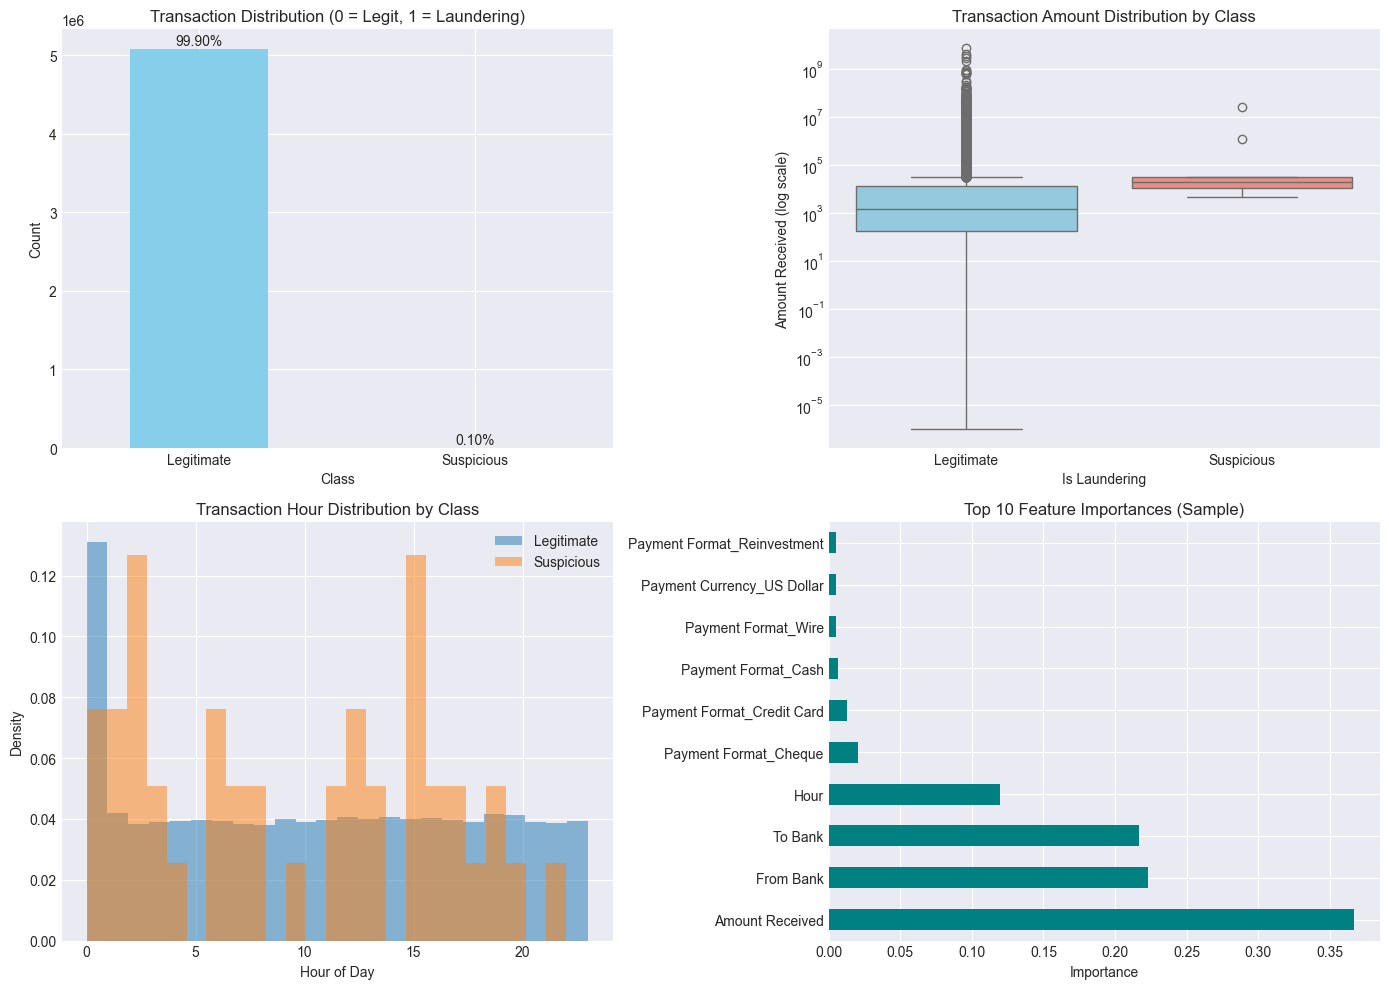

In [7]:
print("\n" + "="*60)
print("TASK 4: Visualizations")
print("="*60)

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class imbalance bar plot
ax = axes[0,0]
y.value_counts().plot(kind='bar', color=['skyblue', 'salmon'], ax=ax)
ax.set_title('Transaction Distribution (0 = Legit, 1 = Laundering)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Legitimate', 'Suspicious'], rotation=0)
# Add percentage annotation
total = len(y)
for i, v in enumerate(y.value_counts()):
    ax.text(i, v + total*0.01, f'{v/total*100:.2f}%', ha='center')

# 2. Boxplot of Amount Received by class (sample to avoid memory)
ax = axes[0,1]
sample_amt = df[['Amount Received', target_col]].sample(min(10000, len(df)))
sns.boxplot(x=target_col, y='Amount Received', data=sample_amt, ax=ax, palette=['skyblue', 'salmon'])
ax.set_title('Transaction Amount Distribution by Class')
ax.set_xticklabels(['Legitimate', 'Suspicious'])
ax.set_yscale('log')  # log scale because amounts vary widely
ax.set_ylabel('Amount Received (log scale)')

# 3. Hour of day distribution by class
ax = axes[1,0]
sample_hour = df[['Hour', target_col]].sample(min(50000, len(df)))
for label in [0,1]:
    subset = sample_hour[sample_hour[target_col] == label]['Hour']
    ax.hist(subset, bins=24, alpha=0.5, label=f'Class {label}', density=True)
ax.set_title('Transaction Hour Distribution by Class')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Density')
ax.legend(['Legitimate', 'Suspicious'])

# 4. Top 10 feature importances from quick Random Forest on sample
ax = axes[1,1]
# Use a sample of 50k rows for quick importance
X_imp = X.sample(50000, random_state=42)
y_imp = y.loc[X_imp.index]
rf_quick = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_quick.fit(X_imp, y_imp)
importances = pd.Series(rf_quick.feature_importances_, index=X_imp.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 10 Feature Importances (Sample)')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('aml_full_plots.png', dpi=150)
print("✅ Visualizations saved as 'aml_full_plots.png'")
plt.show()

#### Train predictive model

In [9]:
print("\n" + "="*60)
print("TASK 5: Predictive Model - FULL DATASET (XGBoost)")
print("="*60)

# X and y are already defined from earlier cells (after cleaning)
print(f"Full dataset shape: {X.shape[0]} rows, {X.shape[1]} features")

# Split into train/test (80/20) - ~4M train, 1M test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} rows, Test set: {X_test.shape[0]} rows")

# Calculate scale_pos_weight to handle imbalance (no SMOTE needed)
# scale_pos_weight = (number of negative samples) / (number of positive samples)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale = neg_count / pos_count
print(f"Class imbalance ratio: {scale:.2f} (negative/positive)")

# Install XGBoost if not already installed
import subprocess
import sys
try:
    import xgboost as xgb
except ImportError:
    print("Installing xgboost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb

# Train XGBoost (scale_pos_weight balances classes)
print("Training XGBoost on full dataset (this may take 30-60 minutes)...")
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    tree_method='hist',      # faster for large data
    verbosity=1
)
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Laundering']))
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Feature importance
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)
print("\nTop 15 important features:")
print(importances)


TASK 5: Predictive Model - FULL DATASET (XGBoost)
Full dataset shape: 5078345 rows, 38 features
Training set: 4062676 rows, Test set: 1015669 rows
Class imbalance ratio: 979.85 (negative/positive)
Installing xgboost...
Training XGBoost on full dataset (this may take 30-60 minutes)...

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.87      0.93   1014634
  Laundering       0.01      0.94      0.01      1035

    accuracy                           0.87   1015669
   macro avg       0.50      0.91      0.47   1015669
weighted avg       1.00      0.87      0.93   1015669

Confusion Matrix:
[[881150 133484]
 [    59    976]]
ROC-AUC Score: 0.9686

Top 15 important features:
Payment Format_Credit Card         0.189621
Payment Format_Reinvestment        0.172302
Payment Format_Cheque              0.116911
Payment Format_Cash                0.093402
Payment Format_Wire                0.080789
Payment Currency_Bitcoin           0.037

#### Project Summary

In [11]:
print("\n" + "="*60)
print("PROJECT COMPLETED - SUMMARY")
print("="*60)
print("✅ Task 1: Data Understanding (5,078,345 rows, 11 columns)")
print("✅ Task 2: Data Cleaning (dropped IDs, extracted Hour, removed redundant amount, one-hot encoded)")
print("✅ Task 3: EDA (class imbalance 0.1%, top correlations: US Dollar, Hour)")
print("✅ Task 4: Visualizations (4 plots saved as 'aml_full_plots.png')")
print(f"✅ Task 5: Predictive Model (XGBoost on full data, scale_pos_weight, ROC-AUC = {roc_auc:.4f})")
print("\n📊 Plots saved as 'aml_full_plots.png'")


PROJECT COMPLETED - SUMMARY
✅ Task 1: Data Understanding (5,078,345 rows, 11 columns)
✅ Task 2: Data Cleaning (dropped IDs, extracted Hour, removed redundant amount, one-hot encoded)
✅ Task 3: EDA (class imbalance 0.1%, top correlations: US Dollar, Hour)
✅ Task 4: Visualizations (4 plots saved as 'aml_full_plots.png')
✅ Task 5: Predictive Model (XGBoost on full data, scale_pos_weight, ROC-AUC = 0.9686)

📊 Plots saved as 'aml_full_plots.png'
